In [ ]:
# Code snippet 0
# Setting the data URL
# Code snippet 0
# Setting the data file
url = 'Sampledatafoodsales.xlsx'

# Displaying the URL
url

'Sampledatafoodsales.xlsx'

In [ ]:
# Code snippet 1
# Importing pandas package for data processing
import pandas

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sampledatafoodsales.xlsx to Sampledatafoodsales.xlsx


In [ ]:
# Code snippet 2
# Importing data from the URL and saving it in a data variable
url = "Sampledatafoodsales.xlsx"

data = pandas.read_excel(url)

# Displaying the data
data

,OrderDate,Region,City,Category,Product,Quantity,UnitPrice,TotalPrice
0,2020-01-01,East,Boston,Bars,Carrot,33,1.77,58.41
1,2020-01-04,East,Boston,Crackers,Whole Wheat,87,3.49,303.63
2,2020-01-07,West,Los Angeles,Cookies,Chocolate Chip,58,1.87,108.46
3,2020-01-10,East,New York,Cookies,Chocolate Chip,82,1.87,153.34
4,2020-01-13,East,Boston,Cookies,Arrowroot,38,2.18,82.84
...,...,...,...,...,...,...,...,...
239,2021-12-18,East,Boston,Cookies,Arrowroot,34,2.18,74.12
240,2021-12-21,East,Boston,Cookies,Chocolate Chip,245,1.87,458.15
241,2021-12-24,East,Boston,Crackers,Whole Wheat,30,3.49,104.70
242,2021-12-27,West,Los Angeles,Bars,Bran,30,1.87,56.10


In [ ]:
# Code snippet 3
# Displaying the dataset columns
data.columns

Index(['OrderDate', 'Region', 'City', 'Category', 'Product', 'Quantity',
       'UnitPrice', 'TotalPrice'],
      dtype='object')

In [ ]:
# Code snippet 4
# Displaying Descriptive statistics of the dataset
data.describe()

,OrderDate,Quantity,UnitPrice,TotalPrice
count,244,244.000000,244.000000,244.000000
mean,2020-12-31 00:00:00,63.286885,2.200820,136.580246
min,2020-01-01 00:00:00,20.000000,1.350000,33.600000
25%,2020-07-02 06:00:00,31.000000,1.770000,72.570000
50%,2020-12-31 12:00:00,47.000000,1.870000,102.755000
75%,2021-06-30 18:00:00,80.000000,2.840000,159.300000
max,2021-12-30 00:00:00,306.000000,3.490000,817.920000
std,NaN,47.112505,0.600169,108.354231


<Axes: >

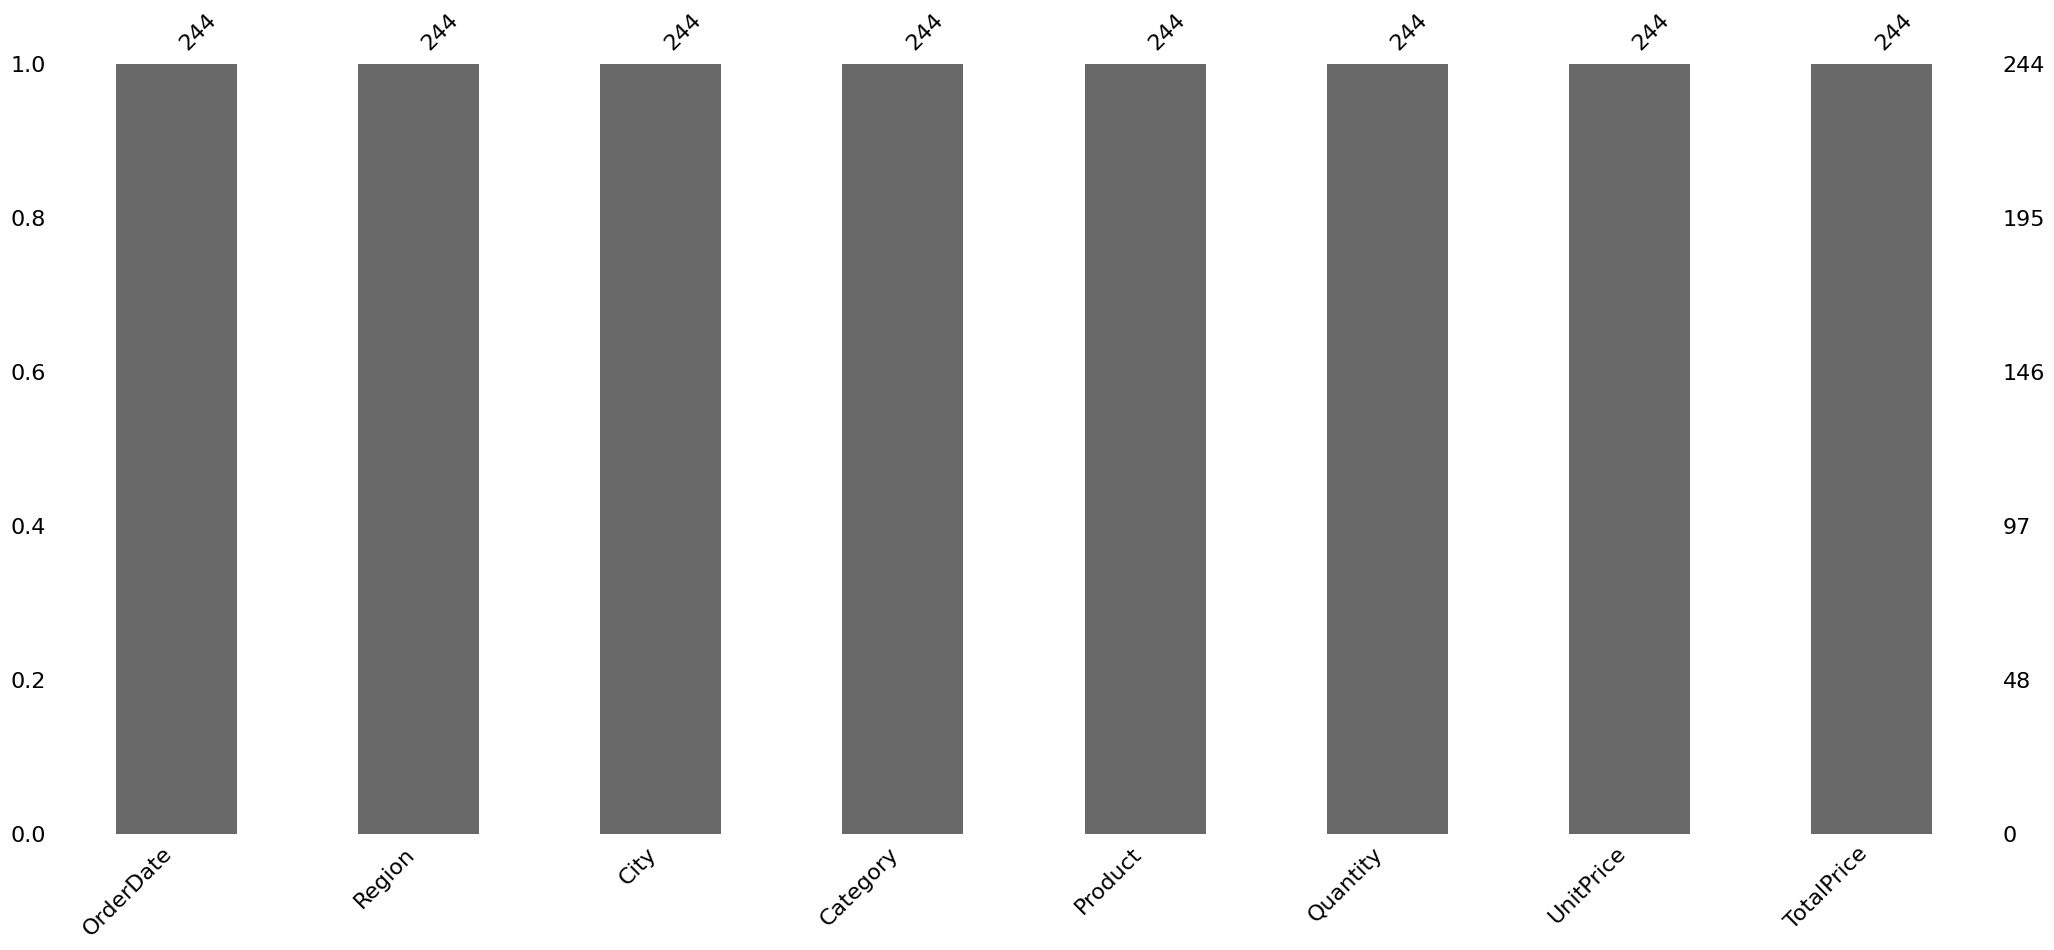

In [ ]:
# Code snippet 5
# Displaying the missing data proportions
import missingno as msno
msno.bar(data)

In [ ]:
# Code snippet 6
# Installing ydata-profiling for a detailed EDA report
!pip install -q ydata-profiling

In [ ]:
# Code snippet 7
# Importing EDA (Exploratory Data Analytics) function
from ydata_profiling import ProfileReport

# Building the detailed report from the dataset
profile = ProfileReport(data, title="Food Sales EDA Report", explorative=True)

# Displaying the full report inside the notebook
profile.to_notebook_iframe()

/tmp/ipykernel_7405/321065944.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 25.36it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Code snippet 7 — Set up plotting

In [ ]:
# Code snippet 7
# Importing plotting packages
import matplotlib.pyplot as plt

# Making the OrderDate column a proper datetime (needed for the time series)
data['OrderDate'] = pandas.to_datetime(data['OrderDate'])

Code snippet 8 — Q1: Which city buys the most products? (pivot table + graph)

In [ ]:
# Code snippet 8
# Q1: City that buys the most products (by total Quantity)
city_qty = data.pivot_table(index='City', values='Quantity', aggfunc='sum')
city_qty = city_qty.sort_values('Quantity', ascending=False)
print(city_qty)


             Quantity
City                 
Boston           5650
New York         4006
Los Angeles      3769
San Diego        2017


Code snippet 9 — Q2: Which region has the highest revenue? (pivot table + graph)

        TotalPrice
Region            
East      21524.36
West      11801.22


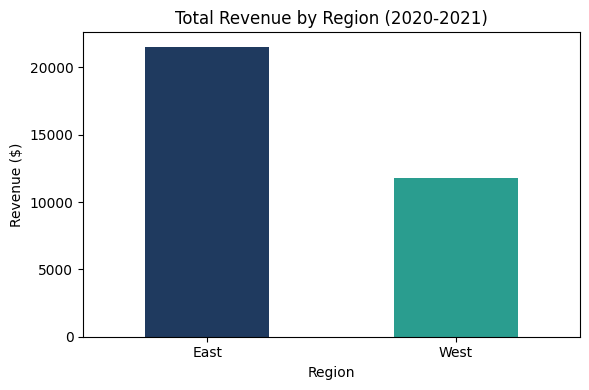

In [ ]:
# Code snippet 9
# Q2: Region with the highest revenue (by total TotalPrice)
region_rev = data.pivot_table(index='Region', values='TotalPrice', aggfunc='sum')
region_rev = region_rev.sort_values('TotalPrice', ascending=False)
print(region_rev)

# Graph
region_rev['TotalPrice'].plot(kind='bar', color=['#1f3a5f', '#2a9d8f'], figsize=(6,4))
plt.title('Total Revenue by Region (2020-2021)')
plt.ylabel('Revenue ($)')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Code snippet 10 — Q3: Most popular category of food? (pivot table + graph)

          Quantity  TotalPrice
Category                      
Cookies       7464    17212.41
Bars          5841    10535.57
Snacks        1180     2237.67
Crackers       957     3339.93


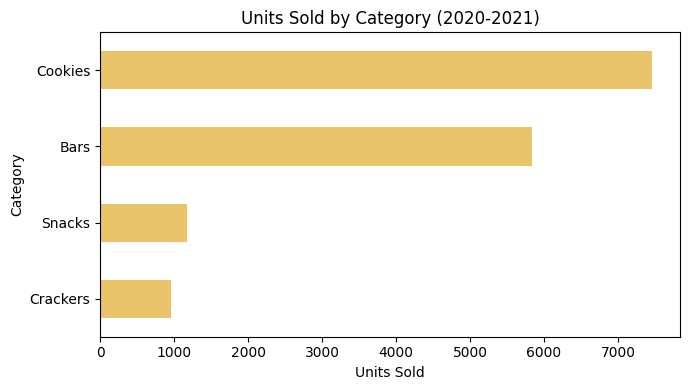

In [ ]:
# Code snippet 10
# Q3: Most popular food category (by total Quantity, with Revenue too)
category = data.pivot_table(index='Category',
                            values=['Quantity', 'TotalPrice'],
                            aggfunc='sum')
category = category.sort_values('Quantity', ascending=False)
print(category)

# Graph
category['Quantity'].sort_values().plot(kind='barh', color='#e9c46a', figsize=(7,4))
plt.title('Units Sold by Category (2020-2021)')
plt.xlabel('Units Sold')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

Code snippet 11 — Q4: Time-series analysis for each product (pivot table + graph)

Product     Arrowroot  Banana    Bran  Carrot  Chocolate Chip  Oatmeal Raisin  \
Month                                                                           
2020-01-01     161.32    0.00    0.00  421.26          261.80            0.00   
2020-02-01      93.74    0.00   78.54  118.59           57.97          443.04   
2020-03-01       0.00    0.00  192.61  175.23          392.70          633.32   
2020-04-01       0.00    0.00    0.00  477.90            0.00            0.00   
2020-05-01      58.86    0.00  196.35  254.88          220.66          391.92   
2020-06-01       0.00    0.00  205.70  748.71          142.12          962.76   
2020-07-01       0.00    0.00  334.73  332.76          140.25          159.04   
2020-08-01      67.58    0.00  140.25  235.41          480.59          389.08   
2020-09-01     477.42    0.00   61.71  568.17          121.55          210.16   
2020-10-01     575.52    0.00    0.00  492.06           91.63            0.00   
2020-11-01     224.54    0.0

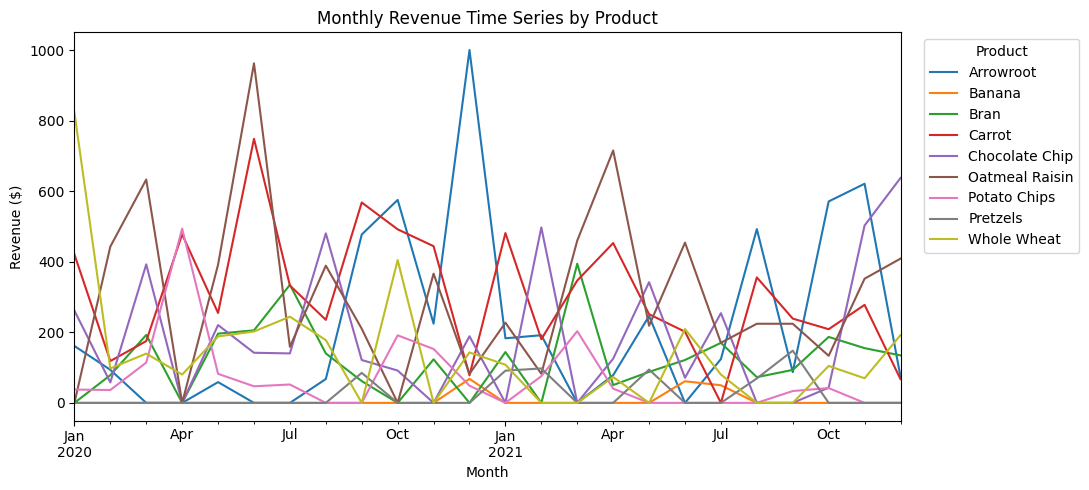

In [ ]:
# Code snippet 11
# Q4: Monthly revenue time series for each product
data['Month'] = data['OrderDate'].dt.to_period('M').dt.to_timestamp()

ts = data.pivot_table(index='Month', columns='Product',
                      values='TotalPrice', aggfunc='sum').fillna(0)
print(ts.round(2))

# Graph - one line per product
ts.plot(figsize=(11,5))
plt.title('Monthly Revenue Time Series by Product')
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Code snippet 12 — Q4 continued: Yearly trend per product (YoY view)

Year               2020     2021  YoY_%
Product                                
Oatmeal Raisin  3638.04  3672.12    0.9
Carrot          4347.12  3063.87  -29.5
Arrowroot       2659.60  2670.50    0.4
Chocolate Chip  2098.14  2474.01   17.9
Bran            1333.31  1611.94   20.9
Whole Wheat     2502.33   837.60  -66.5
Pretzels          85.05   500.85  488.9
Potato Chips    1256.97   394.80  -68.6
Banana            68.10   111.23   63.3


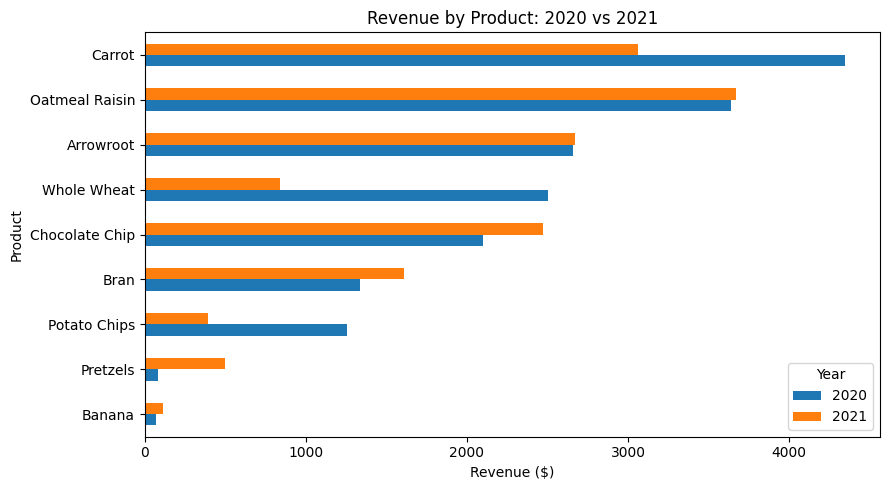

In [ ]:
# Code snippet 12
# Q4: Year-over-year revenue per product to see which are rising/falling
data['Year'] = data['OrderDate'].dt.year
yearly = data.pivot_table(index='Product', columns='Year',
                          values='TotalPrice', aggfunc='sum').fillna(0)
yearly['YoY_%'] = ((yearly[2021] - yearly[2020]) / yearly[2020] * 100).round(1)
print(yearly.sort_values(2021, ascending=False).round(2))

# Graph
yearly[[2020, 2021]].sort_values(2020).plot(kind='barh', figsize=(9,5))
plt.title('Revenue by Product: 2020 vs 2021')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

Code snippet 13 — Q5: Other techniques (correlation analysis + heatmap)

            Quantity  UnitPrice  TotalPrice
Quantity       1.000     -0.096       0.936
UnitPrice     -0.096      1.000       0.182
TotalPrice     0.936      0.182       1.000


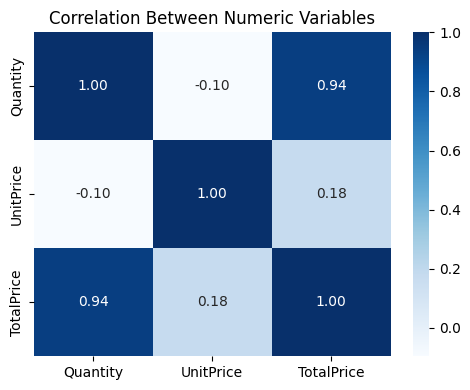

In [ ]:
# Code snippet 13
# Q5: Additional technique - correlation analysis of the numeric fields
import seaborn as sns

corr = data[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
print(corr.round(3))

# Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Between Numeric Variables')
plt.tight_layout()
plt.show()